# BNT Preliminary Results: Graded vs Binary Scoring

This notebook computes cosine similarity scores for Boston Naming Test (BNT) responses using KB-BERT embeddings, and compares graded scoring to binary (exact match) scoring across diagnostic groups.

**Dataset:** 30 BNT items, 100 users, 4 diagnostic groups (HC, MCI, non-AD, AD)

In [1]:
import sys
import re
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from thesis_project.embeddings import KBBertEmbedder, MockEmbedder
from thesis_project.scoring import GradedScorer, compute_cosine_similarity
from thesis_project.preprocessing.normalizer import norm

warnings.filterwarnings('ignore')

# Paths
DATA_PATH = Path('../data/xlsx/BNT-syntheticData_v2.xlsx')
CACHE_PATH = Path('../data/processed/bnt_embeddings_cache.pkl')
OUTPUT_PATH = Path('../data/processed/bnt_scored_results.csv')

print('Setup complete.')

Setup complete.


## 1. Load and Preprocess BNT Data

In [2]:
def load_bnt_data(filepath: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load BNT spreadsheet and separate items from user metadata.
    
    Returns:
        items_df: DataFrame with columns ['gold'] + user columns, one row per BNT item
        user_meta: DataFrame with columns ['user', 'gender', 'age', 'diagnosis']
    """
    raw = pd.read_excel(filepath)
    user_cols = [c for c in raw.columns if c.startswith('User')]
    
    # Items are first 30 rows (before metadata)
    items_df = raw.iloc[:30][['Gold'] + user_cols].copy()
    items_df.rename(columns={'Gold': 'gold'}, inplace=True)
    items_df['gold'] = items_df['gold'].str.strip().str.lower()
    
    # Metadata from rows 32-34 (Gender, Age, Diagnosis)
    user_meta = pd.DataFrame({
        'user': user_cols,
        'gender': raw.iloc[32][user_cols].values,
        'age': pd.to_numeric(raw.iloc[33][user_cols].values, errors='coerce'),
        'diagnosis': raw.iloc[34][user_cols].values,
    })
    
    return items_df, user_meta

items_df, user_meta = load_bnt_data(DATA_PATH)

print(f'Loaded {len(items_df)} BNT items, {len(user_meta)} users')
print(f'\nDiagnosis distribution:')
print(user_meta['diagnosis'].value_counts().to_string())
print(f'\nGold words: {items_df["gold"].tolist()}')

Loaded 30 BNT items, 100 users

Diagnosis distribution:
diagnosis
MCI       30
non-AD    26
HC        25
AD        19

Gold words: ['säng', 'penna', 'visselpipa', 'kam', 'såg', 'helikopter', 'bläckfisk', 'galge', 'kamel', 'kringla', 'racket', 'vulkan', 'pil', 'jordglob', 'bäver', 'noshörning', 'iglo', 'domino', 'rulltrappa', 'hängmatta', 'pelikan', 'pyramid', 'passare', 'dragspel', 'sparris', 'lås', 'ok', 'sfinx', 'spalje', 'gradskiva']


In [3]:
# Non-responses that indicate failure to name (not semantically scorable)
NON_RESPONSES = {
    'hhhm jag vet inte', 'jag vet inte', 'vet inte', 'pass',
    'ingen aning', 'vet ej', 'hmm', 'hm', 'jag kan inte',
    'något sånt', 'nåt sånt', 'nan', '',
}

def normalize_response(text: str) -> str | None:
    """Normalize a BNT response for embedding comparison.
    
    Returns None for non-responses.
    """
    if pd.isna(text) or str(text).strip() == '':
        return None
    
    text = str(text).strip().lower()
    
    # Check non-responses
    if text in NON_RESPONSES:
        return None
    
    # Remove trailing hedges
    text = re.sub(r'\s*(kanske|tror jag|eller nåt|är det|va)$', '', text).strip()
    
    # Remove leading filler phrases
    text = re.sub(
        r'^(det är |det ser ut som |jag tror det är |jag tror |en slags |nån slags |typ |liksom |bild på |säkert )',
        '', text
    ).strip()
    
    # Remove leading articles
    text = re.sub(r'^(en|ett|den|det|de)\s+', '', text).strip()
    
    # Check again after cleaning
    if text in NON_RESPONSES or text == '' or len(text) < 2:
        return None
    
    return text


def preprocess_responses(items_df: pd.DataFrame, user_meta: pd.DataFrame) -> pd.DataFrame:
    """Build long-format response table with normalized responses."""
    user_cols = user_meta['user'].tolist()
    meta_lookup = user_meta.set_index('user')
    
    records = []
    for _, row in items_df.iterrows():
        gold = row['gold']
        for user in user_cols:
            raw_resp = row[user]
            normalized = normalize_response(raw_resp)
            
            # Check exact match
            is_exact = False
            if normalized is not None:
                is_exact = (normalized == gold)
                # Also accept: gold word is the last token
                if not is_exact:
                    tokens = normalized.split()
                    is_exact = (tokens[-1] == gold) if tokens else False
            
            records.append({
                'gold': gold,
                'user': user,
                'diagnosis': meta_lookup.loc[user, 'diagnosis'],
                'age': meta_lookup.loc[user, 'age'],
                'gender': meta_lookup.loc[user, 'gender'],
                'raw_response': raw_resp,
                'normalized': normalized,
                'is_exact_match': is_exact,
                'is_non_response': normalized is None,
            })
    
    return pd.DataFrame(records)

responses = preprocess_responses(items_df, user_meta)

n_total = len(responses)
n_exact = responses['is_exact_match'].sum()
n_non = responses['is_non_response'].sum()
n_to_score = n_total - n_exact - n_non

print(f'Total responses: {n_total}')
print(f'Exact matches: {n_exact} ({100*n_exact/n_total:.1f}%)')
print(f'Non-responses: {n_non} ({100*n_non/n_total:.1f}%)')
print(f'To score with embeddings: {n_to_score} ({100*n_to_score/n_total:.1f}%)')

Total responses: 3000
Exact matches: 1514 (50.5%)
Non-responses: 155 (5.2%)
To score with embeddings: 1331 (44.4%)


## 2. Score Responses with KB-BERT

In [4]:
# Initialize embedder (with caching)
class CachedKBBertEmbedder(KBBertEmbedder):
    """KB-BERT embedder with disk caching."""
    
    def __init__(self, cache_path: Path, **kwargs):
        super().__init__(**kwargs)
        self.cache_path = cache_path
        self._load_cache()
    
    def _load_cache(self):
        if self.cache_path.exists():
            with open(self.cache_path, 'rb') as f:
                self.cache = pickle.load(f)
            print(f'Loaded {len(self.cache)} cached embeddings from {self.cache_path}')
        else:
            print('No cache found, starting fresh.')
    
    def save_cache(self):
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        with open(self.cache_path, 'wb') as f:
            pickle.dump(self.cache, f)
        print(f'Saved {len(self.cache)} embeddings to {self.cache_path}')


# Use real KB-BERT (set USE_MOCK=True to test without GPU)
USE_MOCK = False

if USE_MOCK:
    print('Using MockEmbedder (random embeddings for testing)')
    embedder = MockEmbedder()
else:
    print('Loading KB-BERT...')
    embedder = CachedKBBertEmbedder(CACHE_PATH)
    print('KB-BERT loaded.')

Loading KB-BERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 396.44it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: KB/bert-base-swedish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


No cache found, starting fresh.
KB-BERT loaded.


In [5]:
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_sim

def compute_scores(responses: pd.DataFrame, embedder, batch_size: int = 16) -> pd.DataFrame:
    """Compute cosine similarity scores for all responses."""
    df = responses.copy()
    df['cosine_sim'] = np.nan
    
    # Get unique texts to embed
    gold_words = df['gold'].unique().tolist()
    needs_embedding = df[~df['is_exact_match'] & ~df['is_non_response']]['normalized']
    unique_responses = needs_embedding.dropna().unique().tolist()
    all_texts = list(set(gold_words + unique_responses))
    
    print(f'Embedding {len(gold_words)} gold words + {len(unique_responses)} unique responses = {len(all_texts)} total')
    
    # Embed all texts in batches
    embeddings = {}
    for i in range(0, len(all_texts), batch_size):
        batch = all_texts[i:i+batch_size]
        embs = embedder.embed_batch(batch)
        for text, emb in zip(batch, embs):
            embeddings[text] = emb
        if (i + batch_size) % 100 == 0 or i + batch_size >= len(all_texts):
            print(f'  Embedded {min(i+batch_size, len(all_texts))}/{len(all_texts)}')
    
    # Compute similarity scores
    scores = []
    for _, row in df.iterrows():
        if row['is_exact_match']:
            scores.append(1.0)
        elif row['is_non_response']:
            scores.append(0.0)
        elif row['normalized'] in embeddings:
            gold_emb = embeddings[row['gold']].reshape(1, -1)
            resp_emb = embeddings[row['normalized']].reshape(1, -1)
            sim = sklearn_cosine_sim(gold_emb, resp_emb)[0, 0]
            scores.append(max(0.0, float(sim)))
        else:
            scores.append(0.0)
    
    df['cosine_sim'] = scores
    df['binary_score'] = df['is_exact_match'].astype(int)
    
    return df

scored = compute_scores(responses, embedder, batch_size=16)

# Save cache
if hasattr(embedder, 'save_cache'):
    embedder.save_cache()

print(f'\nScoring complete. Mean graded score: {scored["cosine_sim"].mean():.3f}')

Embedding 30 gold words + 269 unique responses = 297 total
  Embedded 297/297
Saved 297 embeddings to ../data/processed/bnt_embeddings_cache.pkl

Scoring complete. Mean graded score: 0.879


## 3. Results

### 3a. Summary Table: Binary vs Graded Scores by Diagnostic Group

In [6]:
diag_order = ['HC', 'MCI', 'non-AD', 'AD']

summary = []
for diag in diag_order:
    sub = scored[scored['diagnosis'] == diag]
    n_users = sub['user'].nunique()
    user_means = sub.groupby('user')['cosine_sim'].mean()
    
    summary.append({
        'Diagnosis': diag,
        'N_users': n_users,
        'Binary_mean': sub['binary_score'].mean(),
        'Graded_mean': sub['cosine_sim'].mean(),
        'Graded_std': user_means.std(),
        'Graded_minus_Binary': sub['cosine_sim'].mean() - sub['binary_score'].mean(),
        'Non_response_rate': sub['is_non_response'].mean(),
    })

summary_df = pd.DataFrame(summary)
print('Summary: Mean Binary vs Graded Score by Diagnostic Group')
print('=' * 80)
print(summary_df.to_string(index=False, float_format='%.3f'))
print('\nKey insight: Graded_minus_Binary shows how much additional information')
print('graded scoring captures beyond binary correct/incorrect.')

Summary: Mean Binary vs Graded Score by Diagnostic Group
Diagnosis  N_users  Binary_mean  Graded_mean  Graded_std  Graded_minus_Binary  Non_response_rate
       HC       25        0.599        0.935       0.051                0.336              0.004
      MCI       30        0.509        0.886       0.087                0.378              0.046
   non-AD       26        0.479        0.872       0.103                0.392              0.055
       AD       19        0.409        0.805       0.189                0.396              0.119

Key insight: Graded_minus_Binary shows how much additional information
graded scoring captures beyond binary correct/incorrect.


### 3b. Box Plot: Per-User Mean Graded Scores by Diagnostic Group

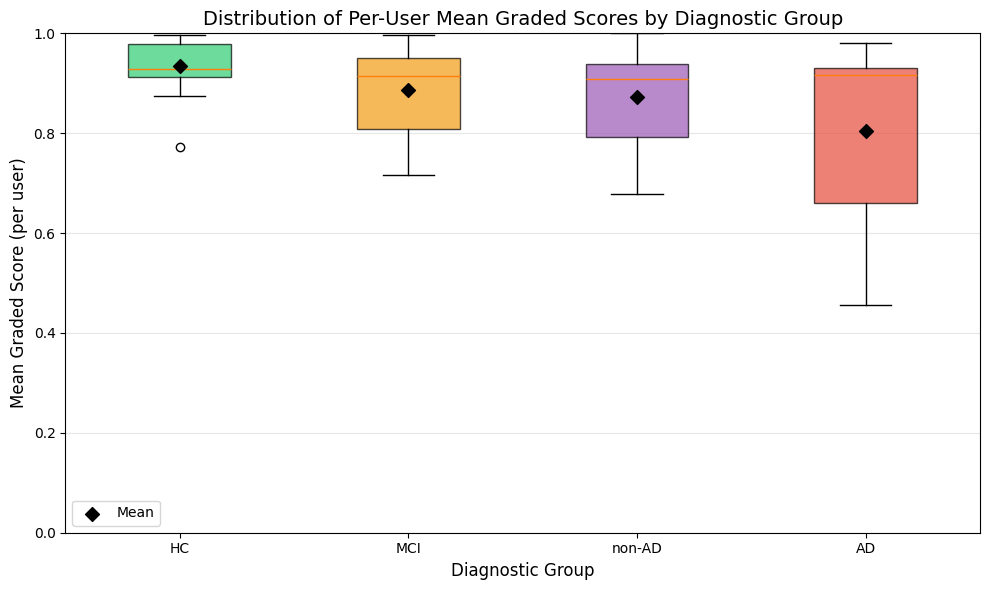

Boxplot saved to data/processed/bnt_boxplot_by_diagnosis.png


In [7]:
# Compute per-user mean scores
user_scores = scored.groupby(['user', 'diagnosis']).agg(
    graded_mean=('cosine_sim', 'mean'),
    binary_mean=('binary_score', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for boxplot
boxplot_data = [user_scores[user_scores['diagnosis'] == diag]['graded_mean'].values 
                for diag in diag_order]

bp = ax.boxplot(boxplot_data, labels=diag_order, patch_artist=True)

# Color boxes
colors = ['#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']  # green, orange, purple, red
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Mean Graded Score (per user)', fontsize=12)
ax.set_xlabel('Diagnostic Group', fontsize=12)
ax.set_title('Distribution of Per-User Mean Graded Scores by Diagnostic Group', fontsize=14)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add mean markers
means = [np.mean(d) for d in boxplot_data]
ax.scatter(range(1, len(diag_order)+1), means, color='black', marker='D', s=50, zorder=3, label='Mean')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/bnt_boxplot_by_diagnosis.png', dpi=150)
plt.show()

print('Boxplot saved to data/processed/bnt_boxplot_by_diagnosis.png')

### 3c. Example Items: Responses for 'kamel', 'bläckfisk', 'sfinx'

In [8]:
example_items = ['kamel', 'bläckfisk', 'sfinx']

for item in example_items:
    print(f"\n{'='*70}")
    print(f"ITEM: '{item}'")
    print('='*70)
    
    item_data = scored[(scored['gold'] == item) & 
                       ~scored['is_exact_match'] & 
                       ~scored['is_non_response']].copy()
    
    if len(item_data) == 0:
        print('  No non-exact responses to show.')
        continue
    
    # Group by normalized response
    resp_analysis = item_data.groupby('normalized').agg(
        count=('user', 'count'),
        cosine_sim=('cosine_sim', 'first'),
        diagnoses=('diagnosis', lambda x: ', '.join(sorted(set(x)))),
    ).reset_index()
    resp_analysis = resp_analysis.sort_values('cosine_sim', ascending=False)
    
    print(f"{'Response':<30} {'Score':>8} {'Count':>6}  Diagnoses")
    print('-' * 70)
    for _, row in resp_analysis.iterrows():
        print(f"{row['normalized'][:30]:<30} {row['cosine_sim']:>8.3f} {row['count']:>6}  {row['diagnoses']}")


ITEM: 'kamel'
Response                          Score  Count  Diagnoses
----------------------------------------------------------------------
djur                              0.977      1  HC
däggdjur                          0.976      1  MCI
häst                              0.975      1  MCI
lama                              0.848      1  AD
stor fågel                        0.830      1  AD
djur i öknen                      0.826      1  MCI
puckelrygg                        0.822      1  non-AD
något med vinklar                 0.803      1  AD
ökenlastdjur                      0.802      1  MCI
puckelkamel                       0.801     13  AD, HC, MCI, non-AD
dromedar                          0.788     11  HC, MCI, non-AD
åsna                              0.766      1  non-AD
ökendjur                          0.751      6  AD, HC, MCI, non-AD

ITEM: 'bläckfisk'
Response                          Score  Count  Diagnoses
---------------------------------------------------------

### 3d. Top/Bottom Responses (Non-Exact Matches)

In [9]:
# Filter to non-exact, non-zero responses
scorable = scored[~scored['is_exact_match'] & ~scored['is_non_response']].copy()

# Get unique response-gold pairs with their scores
unique_pairs = scorable.drop_duplicates(subset=['gold', 'normalized']).copy()
unique_pairs = unique_pairs.sort_values('cosine_sim', ascending=False)

print('TOP 10 Highest Scoring Non-Exact Matches')
print('(These should be near-synonyms or closely related words)')
print('=' * 80)
print(f"{'Gold':<15} {'Response':<30} {'Score':>8}")
print('-' * 80)
for _, row in unique_pairs.head(10).iterrows():
    print(f"{row['gold']:<15} {row['normalized'][:30]:<30} {row['cosine_sim']:>8.3f}")

TOP 10 Highest Scoring Non-Exact Matches
(These should be near-synonyms or closely related words)
Gold            Response                          Score
--------------------------------------------------------------------------------
gradskiva       gradski                           0.990
spalje          spaljé                            0.988
säng            bädd                              0.986
dragspel        instrument                        0.983
kam             sak                               0.982
kamel           djur                              0.977
kamel           däggdjur                          0.976
kam             sax                               0.976
lås             nyckel                            0.976
kamel           häst                              0.975


In [10]:
# Bottom 10 (lowest non-zero scores)
nonzero = unique_pairs[unique_pairs['cosine_sim'] > 0].copy()
nonzero = nonzero.sort_values('cosine_sim', ascending=True)

print('\nBOTTOM 10 Lowest Non-Zero Scores')
print('(Interesting error cases - semantically distant but attempted responses)')
print('=' * 80)
print(f"{'Gold':<15} {'Response':<30} {'Score':>8}")
print('-' * 80)
for _, row in nonzero.head(10).iterrows():
    print(f"{row['gold']:<15} {row['normalized'][:30]:<30} {row['cosine_sim']:>8.3f}")


BOTTOM 10 Lowest Non-Zero Scores
(Interesting error cases - semantically distant but attempted responses)
Gold            Response                          Score
--------------------------------------------------------------------------------
sfinx           mytisk staty med lejonkropp       0.598
bäver           bevär                             0.666
spalje          vet inte riktigt                  0.677
spalje          vet faktiskt inte                 0.683
bäver           djur som bygger dammar            0.692
helikopter      räddningshelikopter               0.693
gradskiva       vad kallas den den heter speci    0.693
penna           kulspetspenna                     0.706
penna           skrivpenna                        0.713
galge           krok                              0.721


### 3e. Score Distribution: Graded Scores for Binary "Incorrect" Responses

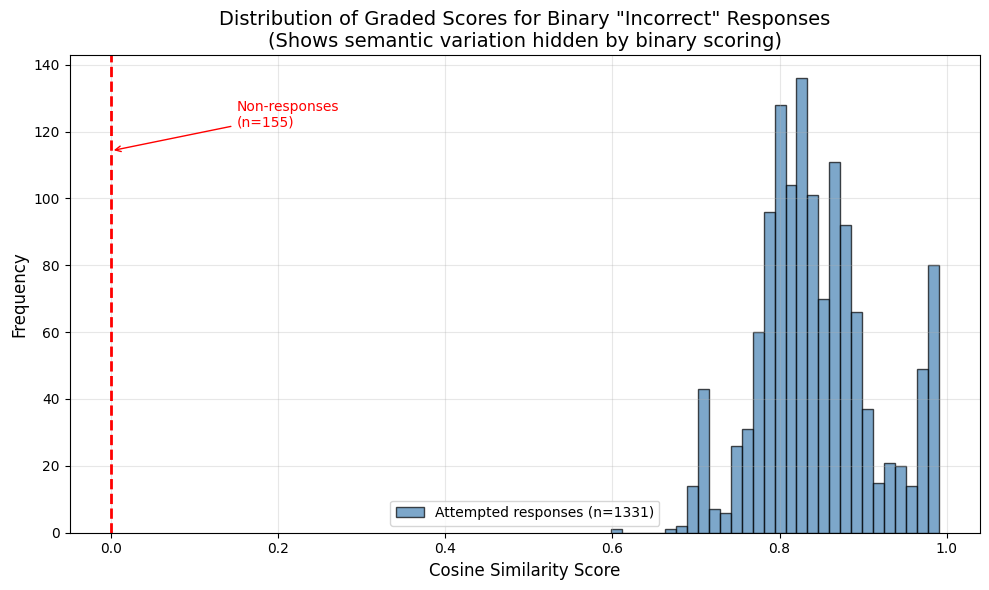


Summary of binary incorrect responses:
  Non-responses (score=0): 155
  Attempted responses: 1331
  Mean score of attempted: 0.844
  Score range: [0.598, 0.990]

Histogram saved to data/processed/bnt_score_distribution.png


In [11]:
# Get all responses that are binary incorrect (not exact match)
binary_incorrect = scored[scored['binary_score'] == 0].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Separate non-responses (score=0) from attempted responses
non_responses = binary_incorrect[binary_incorrect['is_non_response']]
attempted = binary_incorrect[~binary_incorrect['is_non_response']]

# Plot histogram of attempted responses
ax.hist(attempted['cosine_sim'], bins=30, alpha=0.7, color='steelblue', 
        edgecolor='black', label=f'Attempted responses (n={len(attempted)})')

# Add vertical line at non-response count (score=0)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.annotate(f'Non-responses\n(n={len(non_responses)})', 
            xy=(0, ax.get_ylim()[1]*0.8), xytext=(0.15, ax.get_ylim()[1]*0.85),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Graded Scores for Binary "Incorrect" Responses\n'
             '(Shows semantic variation hidden by binary scoring)', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/bnt_score_distribution.png', dpi=150)
plt.show()

print(f'\nSummary of binary incorrect responses:')
print(f'  Non-responses (score=0): {len(non_responses)}')
print(f'  Attempted responses: {len(attempted)}')
print(f'  Mean score of attempted: {attempted["cosine_sim"].mean():.3f}')
print(f'  Score range: [{attempted["cosine_sim"].min():.3f}, {attempted["cosine_sim"].max():.3f}]')
print(f'\nHistogram saved to data/processed/bnt_score_distribution.png')

## 4. Save Results

In [12]:
# Save full scored results
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
scored.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(scored)} scored responses to {OUTPUT_PATH}')

# Save summary table
summary_path = OUTPUT_PATH.parent / 'bnt_summary_by_diagnosis.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved summary table to {summary_path}')

Saved 3000 scored responses to ../data/processed/bnt_scored_results.csv
Saved summary table to ../data/processed/bnt_summary_by_diagnosis.csv


## Key Takeaways

1. **Graded scoring captures more information**: The difference between graded and binary means shows that binary scoring discards meaningful semantic variation.

2. **Group differences**: Compare the boxplot distributions across diagnostic groups to see if graded scoring reveals different patterns than binary scoring alone.

3. **Validation**: The top-scoring non-exact matches should be semantically similar to gold words (near-synonyms, related concepts), validating that KB-BERT embeddings capture Swedish semantic relationships.

4. **Error analysis**: The bottom-scoring responses and the score distribution reveal the range of semantic proximity in "incorrect" responses.